In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(
    "../data/processed/ethiopia_fi_unified_data_enriched.csv"
)

impact = pd.read_csv(
    "../data/processed/impact_links_enriched.csv"
)


df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


In [2]:
df["record_type"].value_counts()

record_type
observation    31
event          11
target          3
Name: count, dtype: int64

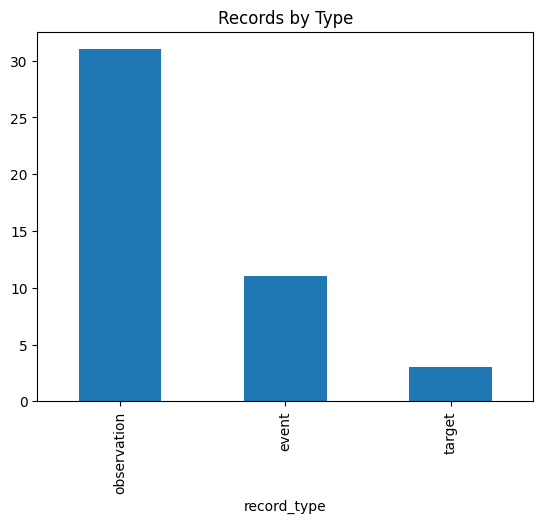

In [3]:
df["record_type"].value_counts().plot(
    kind="bar",
    title="Records by Type"
)

plt.show()

In [4]:
df["pillar"].value_counts()

pillar
ACCESS           16
USAGE            11
GENDER            5
AFFORDABILITY     1
access            1
Name: count, dtype: int64

In [5]:
df["source_type"].value_counts()

source_type
operator      15
survey        11
regulator      7
research       4
policy         4
calculated     2
news           2
Name: count, dtype: int64

In [6]:
df["confidence"].value_counts()

confidence
high      41
medium     4
Name: count, dtype: int64

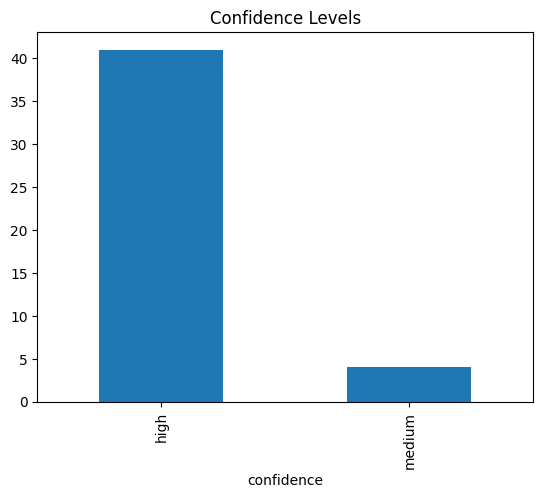

In [7]:
df["confidence"].value_counts().plot(
    kind="bar",
    title="Confidence Levels"
)

plt.show()

In [8]:
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

In [9]:
df["year"] = df["observation_date"].dt.year

In [10]:
coverage = df.groupby(
    ["year","indicator_code"]
).size()

coverage

year  indicator_code    
2014  ACC_OWNERSHIP         1
2017  ACC_OWNERSHIP         1
2021  ACC_MM_ACCOUNT        1
      ACC_OWNERSHIP         3
      EVT_NFIS2             1
      EVT_TELEBIRR          1
      GEN_GAP_ACC           1
2022  EVT_SAFARICOM         1
2023  ACC_4G_COV            1
      EVT_MPESA             1
2024  ACCOUNT_OWNERSHIP     1
      ACC_FAYDA             1
      ACC_MM_ACCOUNT        1
      ACC_OWNERSHIP         1
      AFF_DATA_INCOME       1
      EVT_CROSSOVER         1
      EVT_FAYDA             1
      EVT_FX_REFORM         1
      GEN_GAP_ACC           1
      GEN_GAP_MOBILE        1
      GEN_MM_SHARE          1
      USG_ACTIVE_RATE       1
      USG_MPESA_ACTIVE      1
      USG_MPESA_USERS       1
      USG_P2P_COUNT         1
2025  ACC_4G_COV            1
      ACC_FAYDA             2
      ACC_MOBILE_PEN        1
      ACC_OWNERSHIP         1
      EVT_ETHIOPAY          1
      EVT_MPESA_INTEROP     1
      EVT_SAFCOM_PRICE      1
      USG_ATM_C

In [11]:
account = df[
    df["indicator_code"].str.contains(
        "ACCOUNT",
        na=False
    )
]

account

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
6,REC_0007,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,4.70,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021
7,REC_0008,observation,NaN,ACCESS,Mobile Money Account Rate,ACC_MM_ACCOUNT,higher_better,9.45,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Doubled from 2021,NaN,2024
43,REC_NEW_001,observation,NaN,access,Financial account ownership,ACCOUNT_OWNERSHIP,increase,46.00,46% of adults own an account,percentage,...,NaN,NaN,NaN,NaN,NaN,Hawinet Zewde,2026-07-21,Financial account ownership data from Global F...,Added because account ownership is a key finan...,2024


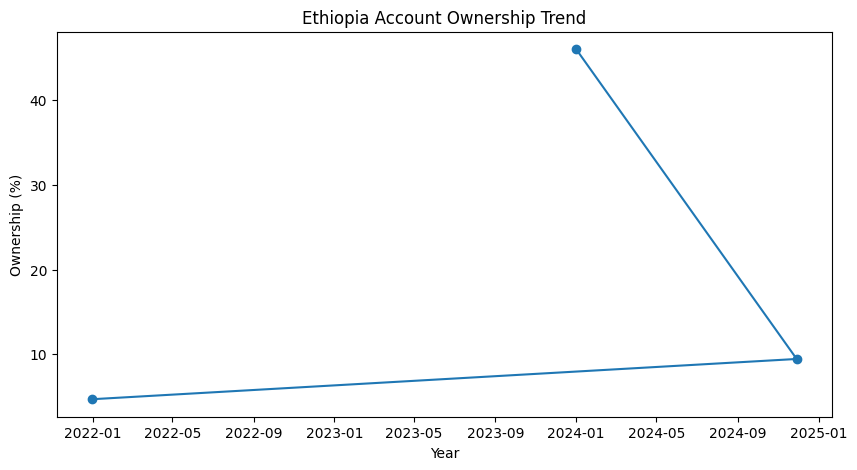

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    account["observation_date"],
    account["value_numeric"],
    marker="o"
)

plt.title(
    "Ethiopia Account Ownership Trend"
)

plt.xlabel("Year")
plt.ylabel("Ownership (%)")

plt.show()

In [13]:
gender = df[
    df["gender"].notna()
]

gender[
[
"gender",
"value_numeric"
]
]

,gender,value_numeric
0,all,2.200000e+01
1,all,3.500000e+01
2,all,4.600000e+01
3,male,5.600000e+01
4,female,3.600000e+01
5,all,4.900000e+01
6,all,4.700000e+00
7,all,9.450000e+00
8,all,3.750000e+01
9,all,7.080000e+01


In [14]:
gender.groupby(
"gender"
)["value_numeric"].mean()

gender
all       1.073895e+11
female    3.333333e+01
male      5.600000e+01
Name: value_numeric, dtype: float64

In [15]:
events = df[
df["record_type"]=="event"
]

events[
[
"record_id",
"category",
"observation_date"
]
]

,record_id,category,observation_date
33,EVT_0001,product_launch,2021-05-17
34,EVT_0002,market_entry,2022-08-01
35,EVT_0003,product_launch,2023-08-01
36,EVT_0004,infrastructure,2024-01-01
37,EVT_0005,policy,2024-07-29
38,EVT_0006,milestone,2024-10-01
39,EVT_0007,partnership,2025-10-27
40,EVT_0008,infrastructure,2025-12-18
41,EVT_0009,policy,2021-09-01
42,EVT_0010,pricing,2025-12-15


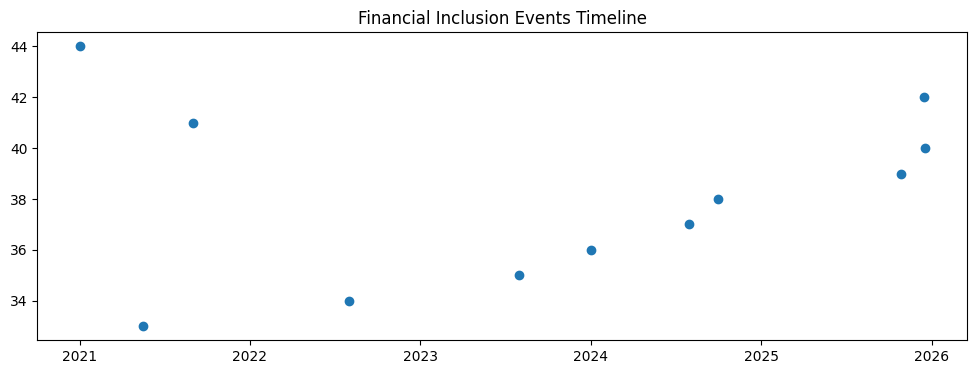

In [16]:
plt.figure(figsize=(12,4))

plt.scatter(
events["observation_date"],
events.index
)

plt.title("Financial Inclusion Events Timeline")

plt.show()

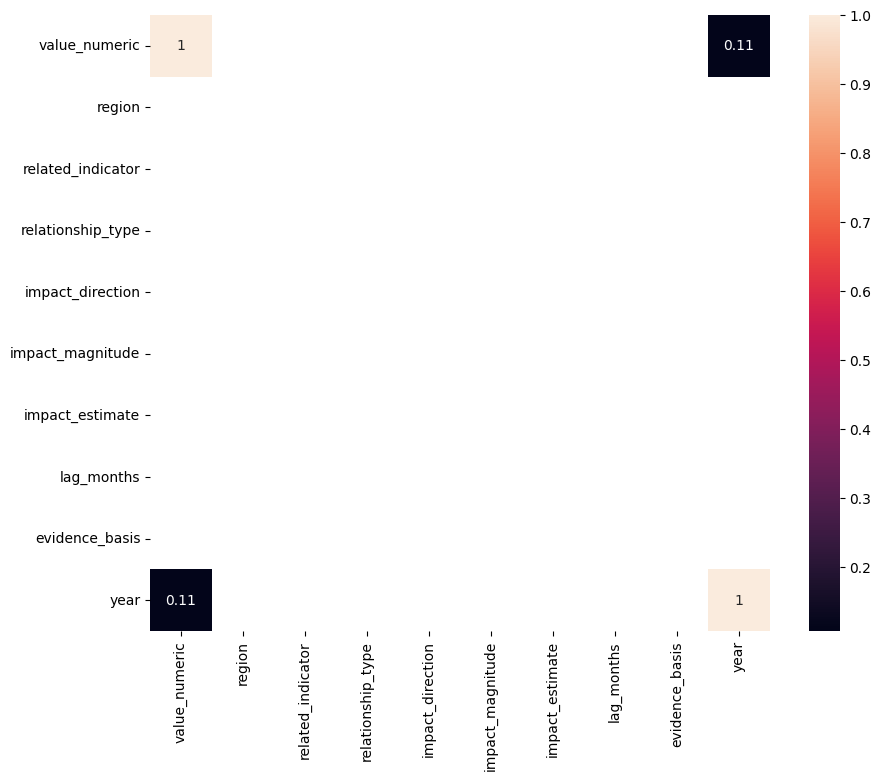

In [18]:
numeric = df.select_dtypes(
include="number"
)

corr = numeric.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
corr,
annot=True
)

plt.show()